In [61]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
from patsy import dmatrices
import statsmodels.discrete.discrete_model as sm
import statsmodels.formula.api as smf
import statsmodels.api as sma
from statsmodels.graphics.regressionplots import *
from sklearn import datasets, linear_model
from sklearn.metrics import confusion_matrix
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn import preprocessing

In [2]:
Smarket = pd.read_csv('datasets/Smarket.csv')

In [3]:
Smarket.head()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,2001,0.381,-0.192,-2.624,-1.055,5.010,1.1913,0.959,Up
1,2001,0.959,0.381,-0.192,-2.624,-1.055,1.2965,1.032,Up
2,2001,1.032,0.959,0.381,-0.192,-2.624,1.4112,-0.623,Down
3,2001,-0.623,1.032,0.959,0.381,-0.192,1.2760,0.614,Up
4,2001,0.614,-0.623,1.032,0.959,0.381,1.2057,0.213,Up


O volume de negociação representa a quantidade total de um ativo (como ações de empresas) comprada e vendida no mercado em um determinado período de tempo (quantidade de ações negociadas no dia, expressa em bilhões)

O retorno percentual mede a variação de preço de um ativo entre dois momentos, mostrando o ganho ou a perda em porcentagem em relação ao valor inicial.

Exemplo: Se uma ação custava US$ 100 ontem e hoje está custando US$ 101, o retorno percentual do dia foi de +1%. Se ela caiu para US$ 99, o retorno foi de -1%.

In [4]:
Smarket.shape

(1250, 9)

In [5]:
Smarket.columns

Index(['Year', 'Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume', 'Today',
       'Direction'],
      dtype='str')

In [6]:
Smarket.info()

<class 'pandas.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Year       1250 non-null   int64  
 1   Lag1       1250 non-null   float64
 2   Lag2       1250 non-null   float64
 3   Lag3       1250 non-null   float64
 4   Lag4       1250 non-null   float64
 5   Lag5       1250 non-null   float64
 6   Volume     1250 non-null   float64
 7   Today      1250 non-null   float64
 8   Direction  1250 non-null   str    
dtypes: float64(7), int64(1), str(1)
memory usage: 88.0 KB


In [7]:
Smarket.corr(numeric_only=True)

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
Year,1.000000,0.029700,0.030596,0.033195,0.035689,0.029788,0.539006,0.030095
Lag1,0.029700,1.000000,-0.026294,-0.010803,-0.002986,-0.005675,0.040910,-0.026155
Lag2,0.030596,-0.026294,1.000000,-0.025897,-0.010854,-0.003558,-0.043383,-0.010250
Lag3,0.033195,-0.010803,-0.025897,1.000000,-0.024051,-0.018808,-0.041824,-0.002448
Lag4,0.035689,-0.002986,-0.010854,-0.024051,1.000000,-0.027084,-0.048414,-0.006900
Lag5,0.029788,-0.005675,-0.003558,-0.018808,-0.027084,1.000000,-0.022002,-0.034860
Volume,0.539006,0.040910,-0.043383,-0.041824,-0.048414,-0.022002,1.000000,0.014592
Today,0.030095,-0.026155,-0.010250,-0.002448,-0.006900,-0.034860,0.014592,1.000000


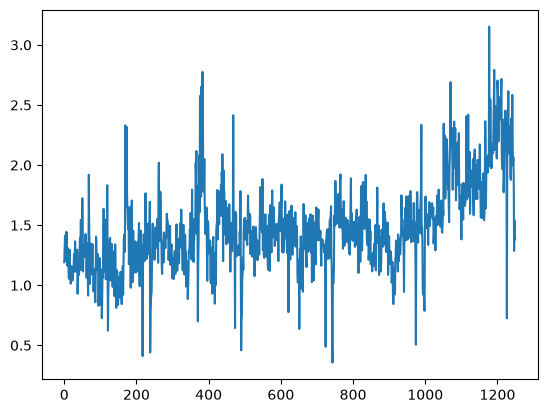

In [8]:
plt.plot(Smarket[['Volume']])
plt.show()

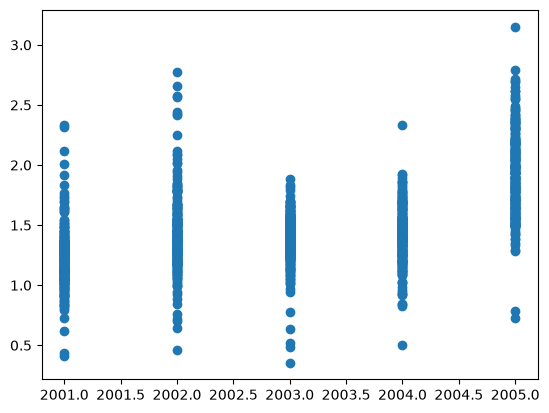

In [9]:
plt.scatter(Smarket[['Year']],Smarket[['Volume']])

In [10]:
y, X = dmatrices('Direction~Lag1+Lag2+Lag3+Lag5+Volume', Smarket,return_type='dataframe')
print(y)

      Direction[Down]  Direction[Up]
0                 0.0            1.0
1                 0.0            1.0
2                 1.0            0.0
3                 0.0            1.0
4                 0.0            1.0
...               ...            ...
1245              0.0            1.0
1246              1.0            0.0
1247              0.0            1.0
1248              1.0            0.0
1249              1.0            0.0

[1250 rows x 2 columns]


In [11]:
logit = sm.Logit(y.iloc[:,1],X)
logit.fit().summary()

Optimization terminated successfully.
         Current function value: 0.691048
         Iterations 4


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:          Direction[Up]   No. Observations:                 1250
Model:                          Logit   Df Residuals:                     1244
Method:                           MLE   Df Model:                            5
Date:                Wed, 30 Sep 2026   Pseudo R-squ.:                0.002054
Time:                        21:53:15   Log-Likelihood:                -863.81
converged:                       True   LL-Null:                       -865.59
Covariance Type:            nonrobust   LLR p-value:                    0.6150
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1238      0.240     -0.515      0.607      -0.595       0.347
Lag1          -0.0731      0.050     -1.457      0.145      -0.171       0.025
Lag2          -0.0424      0.050     -0.847      0.397      -0.141       0.056
Lag3           0.0108      0.050      0.217      0.828      -0.087       0.109
Lag5           0.0100      0.049      0.203      0.839      -0.087       0.107
Volume         0.1340      0.158      0.847      0.397      -0.176       0.444
==============================================================================
"""

In [12]:
logit.fit().params

Optimization terminated successfully.
         Current function value: 0.691048
         Iterations 4


Intercept   -0.123787
Lag1        -0.073096
Lag2        -0.042435
Lag3         0.010829
Lag5         0.010046
Volume       0.133955
dtype: float64

In [13]:
logit.fit().predict()[0:10]

Optimization terminated successfully.
         Current function value: 0.691048
         Iterations 4


array([0.50950051, 0.48773799, 0.48172973, 0.51433146, 0.5085696 ,
       0.50454866, 0.49400182, 0.50780718, 0.51711988, 0.48568204])

In [14]:
threshold = 0.5
predict_label = pd.DataFrame(np.zeros(shape=(1250,1)), columns = ['label'])
predict_label.iloc[logit.fit().predict() > threshold] = 1

Optimization terminated successfully.
         Current function value: 0.691048
         Iterations 4


In [15]:
predict_label

,label
0,1.0
1,0.0
2,0.0
3,1.0
4,1.0
...,...
1245,1.0
1246,1.0
1247,1.0
1248,1.0


In [16]:
confusion_matrix(y.iloc[:,1], predict_label.iloc[:,0])

array([[142, 460],
       [136, 512]])

In [17]:
print(np.mean(y.iloc[:,1] == predict_label.iloc[:,0]))

0.5232


# Train validation

In [24]:
Smarket_train = Smarket.query('Year < 2005')
Smarket_2005 = Smarket.query('Year >= 2005')

In [58]:
y_train, X_train = dmatrices('Direction~Lag1+Lag2+Lag3+Lag4+Lag5+Volume', Smarket_train,return_type='dataframe')
y_test, X_test = dmatrices('Direction~Lag1+Lag2+Lag3+Lag4+Lag5+Volume', Smarket_2005,return_type='dataframe')

In [62]:
X_train = Smarket_train[['Lag1','Lag2','Lag3','Lag4','Lag5','Volume']]
X_train = sma.add_constant(X_train)
logit = sm.Logit(y_train.iloc[:,1], X_train)
print(logit.fit().summary())

Optimization terminated successfully.
         Current function value: 0.691936
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:          Direction[Up]   No. Observations:                  998
Model:                          Logit   Df Residuals:                      991
Method:                           MLE   Df Model:                            6
Date:                Wed, 30 Sep 2026   Pseudo R-squ.:                0.001562
Time:                        23:22:36   Log-Likelihood:                -690.55
converged:                       True   LL-Null:                       -691.63
Covariance Type:            nonrobust   LLR p-value:                    0.9044
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1912      0.334      0.573      0.567      -0.463       0.845
Lag1          -0.0542      0.

In [44]:
#X_train = Smarket_train[["Lag1","Lag2","Lag3","Lag4","Lag5","Volume"]]
#y_train = Smarket_train["Direction"]
#y_train = np.where(y_train == 'Up', 1,0)
#logit = sm.Logit(y_train,X_train)
#print(logit.fit().summary())

In [54]:
logit = sm.Logit(y_train['Direction[Up]'],X_train)
print(logit.fit().summary())

Optimization terminated successfully.
         Current function value: 0.691936
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:          Direction[Up]   No. Observations:                  998
Model:                          Logit   Df Residuals:                      991
Method:                           MLE   Df Model:                            6
Date:                Wed, 30 Sep 2026   Pseudo R-squ.:                0.001562
Time:                        22:56:56   Log-Likelihood:                -690.55
converged:                       True   LL-Null:                       -691.63
Covariance Type:            nonrobust   LLR p-value:                    0.9044
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1912      0.334      0.573      0.567      -0.463       0.845
Lag1          -0.0542      0.

In [21]:
preds = logit.fit(disp=1).predict(X_test)

Optimization terminated successfully.
         Current function value: 0.691936
         Iterations 4


In [67]:
predict_label = np.where(preds > threshold, 1, 0)
confusion_matrix(y_test["Direction[Up]"], predict_label)

array([[77, 34],
       [97, 44]])

In [68]:
np.mean(y_test["Direction[Up]"]==predict_label)

np.float64(0.4801587301587302)

In [69]:
y_train, X_train = dmatrices('Direction~Lag1+Lag2', Smarket_train, return_type = 'dataframe')
y_test, X_test = dmatrices('Direction~Lag1+Lag2', Smarket_2005, return_type = 'dataframe')

logit = sm.Logit(y_train["Direction[Up]"], X_train)
preds = logit.fit(disp=0).predict(X_test)
predict_label = np.where(preds > threshold, 1, 0)

In [70]:
threshold = 0.5
confusion_matrix(y_test["Direction[Up]"], predict_label)

array([[ 35,  76],
       [ 35, 106]])

In [71]:
np.mean(y_test["Direction[Up]"]==predict_label)

np.float64(0.5595238095238095)

In [73]:
preds = logit.fit(disp=0).predict(X_test)
threshold = 1
predict_label = np.where(preds > threshold, 1, 0)
confusion_matrix(y_test["Direction[Up]"], predict_label)

array([[111,   0],
       [141,   0]])